In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer,make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.preprocessing import StandardScaler,OneHotEncoder,FunctionTransformer
from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
data=pd.read_csv('data/housing.csv')
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [3]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Data Preprocessing

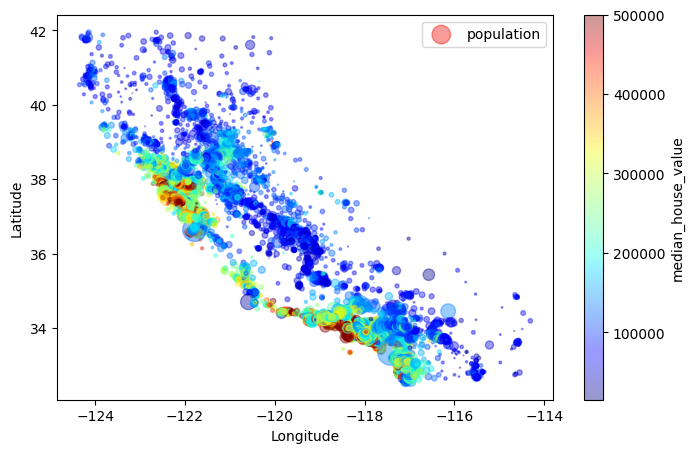

In [10]:
data.plot(kind='scatter',x='longitude',y='latitude',alpha=0.4,
    s=data['population']/100,label='population',
    c='median_house_value',cmap='jet',colorbar=True,figsize=(8,5))
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.savefig('Images/Visualization.png')
plt.show()

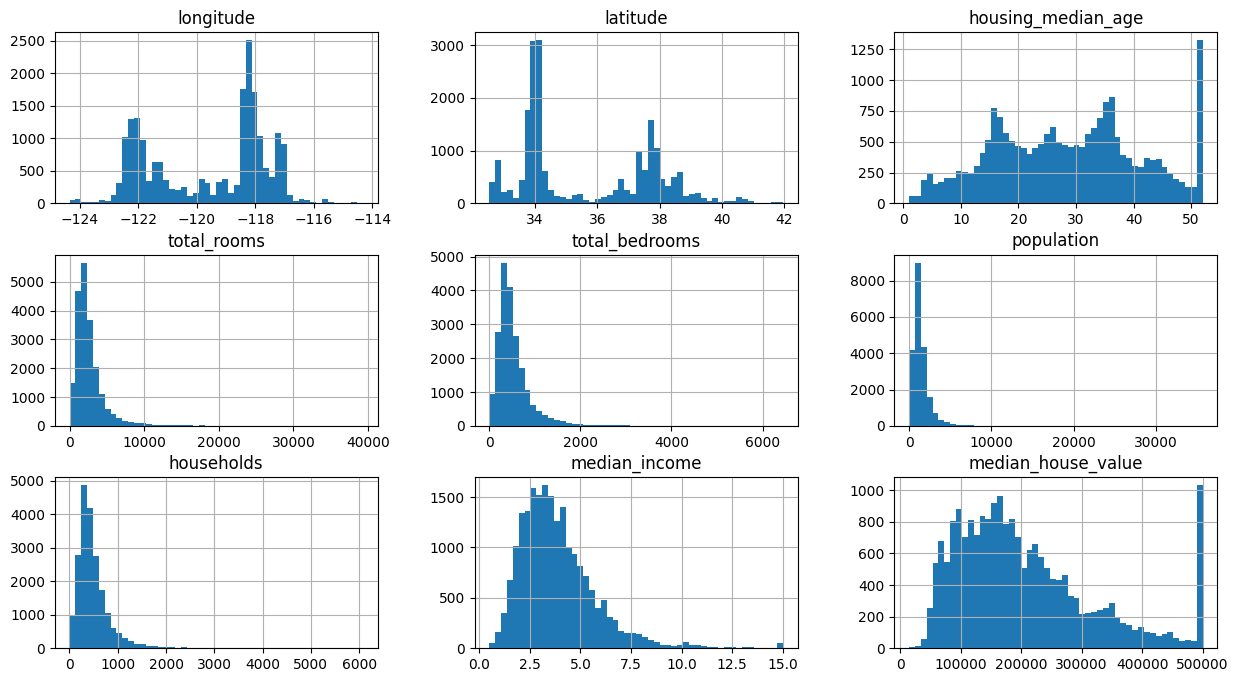

In [11]:
data.hist(bins=50,figsize=(15,8)) #log_pipeline for total_rooms,total_bedrooms,population,households,median_income
plt.savefig('Images/Correlation.png')

In [6]:
train_X,test_X,train_y,test_y = train_test_split(
        data.drop('median_house_value',axis=1),
        data['median_house_value'],test_size=0.2,random_state=42
    )

In [7]:
class cluster_similarity(BaseEstimator,TransformerMixin):
        def __init__(self,n_clusters=10,gamma=0.9,random_state=42):
            self.n_clusters=n_clusters
            self.gamma=gamma
            self.random_state=random_state
        def fit(self,X,y=None,sample_weight=None):
            self.kmeans=KMeans(self.n_clusters,random_state=self.random_state)
            self.kmeans.fit(X,sample_weight)
            return self
        def transform(self,X):
                return rbf_kernel(X,self.kmeans.cluster_centers_,gamma=self.gamma)
cat_pipeline = make_pipeline(
        SimpleImputer(strategy='most_frequent'),
        OneHotEncoder(handle_unknown='ignore'))
num_pipeline = make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler())
log_pipeline =make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(np.log,feature_names_out='one-to-one'),
        StandardScaler())
def ratio_col():
    return make_pipeline(SimpleImputer(strategy='median'),
                FunctionTransformer(
                        lambda x:((x[:,0]/x[:,1] + 1e-8).reshape(-1,1))
                ),
                StandardScaler())

preprocessing=make_column_transformer(
        (ratio_col(),["population","households"]),
        (ratio_col(),['total_rooms','households']),
        (ratio_col(),['total_bedrooms','total_rooms']),
        (cat_pipeline,make_column_selector(dtype_include=object)),
        (log_pipeline,['total_rooms','total_bedrooms','population','households','median_income']),
        (cluster_similarity(n_clusters=10,gamma=0.9,random_state=42),['latitude','longitude'])
        ,remainder=num_pipeline)
pred=preprocessing.fit_transform(train_X)

Training and Evaluating on training set

In [8]:
models={
    'Linear Regression':LinearRegression(),
    'Decision Tree':DecisionTreeRegressor(random_state=42),
    'Random Forest':RandomForestRegressor(random_state=42),
    'SVM':SVR(),
    'KNN':KNeighborsRegressor(),
    'Ridge':Ridge(random_state=42,alpha=0.1,solver='cholesky'),
    'Lasso':Lasso(random_state=42,alpha=0.1),
    'ElasticNet':ElasticNet(alpha=0.1,l1_ratio=0.5)
}
final_result= pd.DataFrame(columns=['Model','RMSE','CV_RMSE'])
for name,model in models.items():
    final_pipeline=make_pipeline(preprocessing,model)
    final_pipeline.fit(train_X,train_y)
    result=final_pipeline.predict(test_X).round(-2)
    final_result.loc[len(final_result)]=[name,root_mean_squared_error(test_y,result),
        -cross_val_score(final_pipeline,test_X,test_y,scoring='neg_root_mean_squared_error',cv=7).mean().round(-2)]

c:\Users\Manoj S\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.700e+13, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(
c:\Users\Manoj S\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.093e+12, tolerance: 4.617e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\Manoj S\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

In [9]:
final_results=final_result.sort_values('CV_RMSE',ascending=True).round()
final_results  # From this we found out that Random Forest model is the best for this dataset

,Model,RMSE,CV_RMSE
2,Random Forest,47938.0,54000.0
4,KNN,61450.0,65500.0
1,Decision Tree,68531.0,74300.0
7,ElasticNet,74582.0,74800.0
5,Ridge,87120.0,82800.0
6,Lasso,86873.0,82800.0
0,Linear Regression,87190.0,82900.0
3,SVM,116875.0,117500.0


In [13]:
final_results.to_csv("Result/final_results.csv",index=False)